In [1]:
# ============================================================
# 🔴 Step 1: Import Required Libraries
# Run Once
# ============================================================

import os
import cv2
import torch
import ultralytics
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("=" * 60)
print("YOLOv10n Environment")
print("=" * 60)

print(f"Ultralytics Version : {ultralytics.__version__}")
print(f"PyTorch Version     : {torch.__version__}")
print(f"CUDA Available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name            : {torch.cuda.get_device_name(0)}")
    print(f"GPU Count           : {torch.cuda.device_count()}")

print("=" * 60)
print("✅ Environment Ready!")
print("=" * 60)

YOLOv10n Environment
Ultralytics Version : 8.4.80
PyTorch Version     : 2.12.1+cu126
CUDA Available      : True
GPU Name            : NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU Count           : 1
✅ Environment Ready!


In [2]:
# ============================================================
# 🔴 Step 2: Verify Dataset
# Run Once
# ============================================================

DATASET_PATH = r"D:\Major Project\Self-Driving Cars.yolov8"
DATA_YAML = os.path.join(DATASET_PATH, "data.yaml")

print("=" * 60)
print("Dataset Verification")
print("=" * 60)

print("Dataset Folder Exists :", os.path.exists(DATASET_PATH))
print("data.yaml Exists      :", os.path.exists(DATA_YAML))

for folder in ["train", "valid", "test"]:
    folder_path = os.path.join(DATASET_PATH, folder)
    print(f"{folder:<8}: {os.path.exists(folder_path)}")

print("=" * 60)

Dataset Verification
Dataset Folder Exists : True
data.yaml Exists      : True
train   : True
valid   : True
test    : True


In [3]:
# ============================================================
# 🔴 Step 3: Training Configuration
# Run Once
# ============================================================

IMG_SIZE = 640
BATCH_SIZE = 16
EPOCHS = 50

DEVICE = 0
WORKERS = 0

PATIENCE = 10
SEED = 42

PROJECT_NAME = r"D:\Major Project\Models"
RUN_NAME = "YOLOv10n"

print("=" * 60)
print("Training Configuration")
print("=" * 60)

print(f"Image Size : {IMG_SIZE}")
print(f"Batch Size : {BATCH_SIZE}")
print(f"Epochs     : {EPOCHS}")
print(f"Patience   : {PATIENCE}")

print("=" * 60)

Training Configuration
Image Size : 640
Batch Size : 16
Epochs     : 50
Patience   : 10


In [4]:
from ultralytics import YOLO

model = YOLO("yolov10n.pt")
print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0

In [4]:
# ============================================================
# 🔴 Step 5: Load YOLOv10n Model
# Run Once
# ============================================================

print("=" * 60)
print("Loading YOLOv10n Pretrained Model...")
print("=" * 60)

model = YOLO("yolov10n.pt")

print("✅ YOLOv10n Model Loaded Successfully!")

model.info()

Loading YOLOv10n Pretrained Model...
✅ YOLOv10n Model Loaded Successfully!
YOLOv10n summary: 223 layers, 2,775,520 parameters, 0 gradients, 8.7 GFLOPs


(223, 2775520, 0, 8.7404288)

In [5]:
# ============================================================
# 🔴 Step 6: Train YOLOv10n
# Run Once
# ============================================================

print("=" * 60)
print("Starting YOLOv10n Training...")
print("=" * 60)

results = model.train(

    data=DATA_YAML,

    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,

    device=DEVICE,
    workers=WORKERS,

    optimizer="auto",
    patience=PATIENCE,
    seed=SEED,

    pretrained=True,
    amp=True,

    project=PROJECT_NAME,
    name=RUN_NAME,

    save=True,
    exist_ok=True,

    plots=True,
    verbose=True
)

print("\n" + "=" * 60)
print("✅ Training Completed Successfully!")
print("=" * 60)

print(f"📁 Model Saved To:\n{PROJECT_NAME}\\{RUN_NAME}")

Starting YOLOv10n Training...
New https://pypi.org/project/ultralytics/8.4.106 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.80  Python-3.12.10 torch-2.12.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Major Project\Self-Driving Cars.yolov8\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, 

In [6]:
# ============================================================
# 🔴 Step 7: Validate Best YOLOv10n Model
# Run Once
# ============================================================

from ultralytics import YOLO

best_model = YOLO(r"D:\Major Project\Models\YOLOv10n\weights\best.pt")

metrics = best_model.val(
    data=DATA_YAML,
    split="test",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    plots=True,
    save_json=True
)

print(metrics)

Ultralytics 8.4.80  Python-3.12.10 torch-2.12.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLOv10n summary (fused): 102 layers, 2,268,093 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 150.7181.8 MB/s, size: 90.7 KB)
val: Scanning D:\Major Project\Self-Driving Cars.yolov8\test\labels.cache... 638 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 638/638  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 2.2it/s 18.1s0.4s
                   all        638        770      0.908      0.881      0.936      0.809
           Green Light         77        110      0.886      0.755      0.888      0.532
             Red Light         71         94      0.855       0.69      0.753      0.475
        Speed Limit 10          2          3      0.582      0.667      0.806       0.73
       Speed Limit 100         45         46      0.881      0.978      0.976      0.883
 

In [1]:
# ============================================================
# 📚 Import Required Libraries
# Run Once
# ============================================================

# Deep Learning
from ultralytics import YOLO

# Computer Vision
import cv2

# Numerical Operations
import numpy as np

# Data Handling
import pandas as pd

# Image Display
import matplotlib.pyplot as plt
from PIL import Image

# File & Folder Operations
import os
import shutil

# File Picker
from tkinter import Tk, filedialog

# Display DataFrame in Jupyter
from IPython.display import display

# Optional: Better Matplotlib display in Jupyter
%matplotlib inline

print("=" * 60)
print("✅ All Libraries Imported Successfully!")
print("=" * 60)

✅ All Libraries Imported Successfully!


In [2]:
# ============================================================
# 🟢 Step 9A: Load Best YOLOv10n Model
# Run Once
# ============================================================

from ultralytics import YOLO

# Path to the best trained model
MODEL_PATH = r"D:\Major Project\Models\YOLOv10n\weights\best.pt"

# Load model
best_model = YOLO(MODEL_PATH)

print("=" * 60)
print("✅ YOLOv10n Best Model Loaded Successfully!")
print("=" * 60)
print(f"📁 Model Path:\n{MODEL_PATH}")

✅ YOLOv10n Best Model Loaded Successfully!
📁 Model Path:
D:\Major Project\Models\YOLOv10n\weights\best.pt


Selected Image: D:/Major Project/Test_images/speed80.jpeg

ORIGINAL


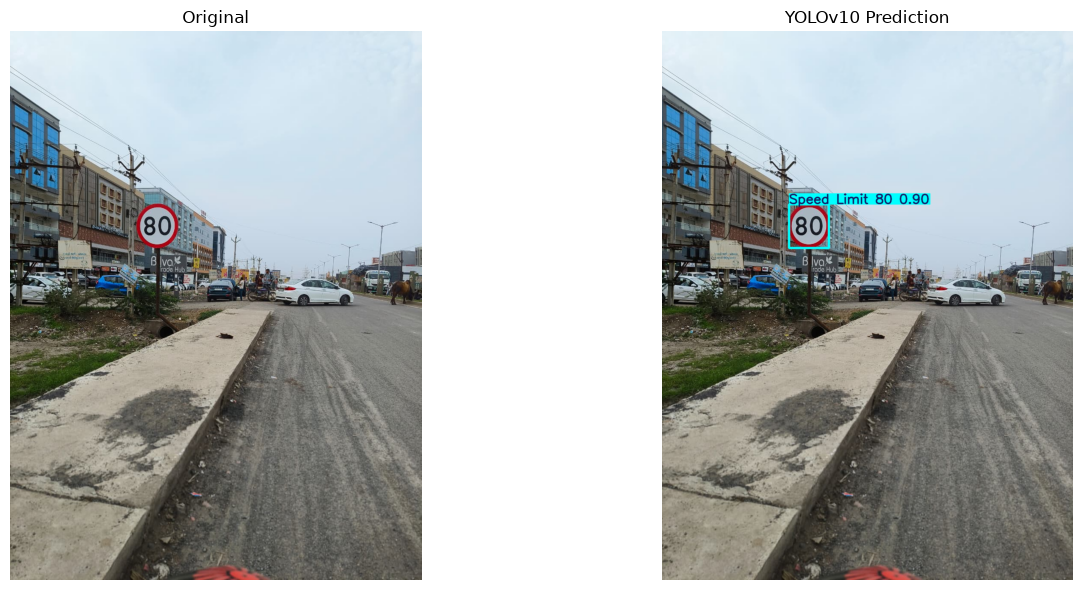

,No.,Traffic Sign,Confidence (%),Width (px),Height (px)
0,1,Speed Limit 80,89.74,93,102


⏱ Total Execution Time : 921.73 ms

NIGHT VISION


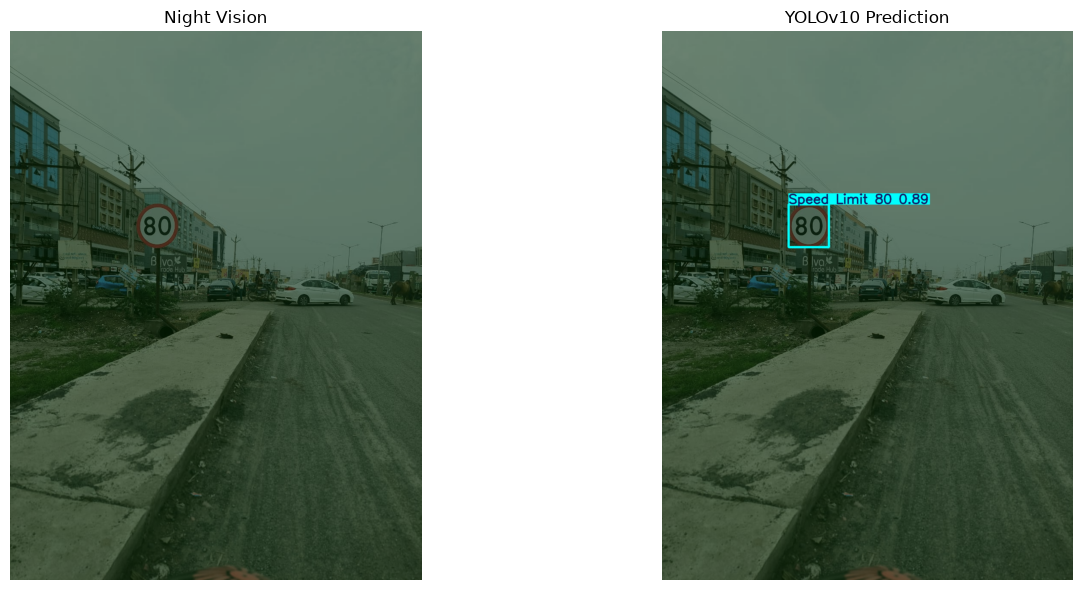

,No.,Traffic Sign,Confidence (%),Width (px),Height (px)
0,1,Speed Limit 80,88.67,94,100


⏱ Total Execution Time : 114.82 ms

FOG


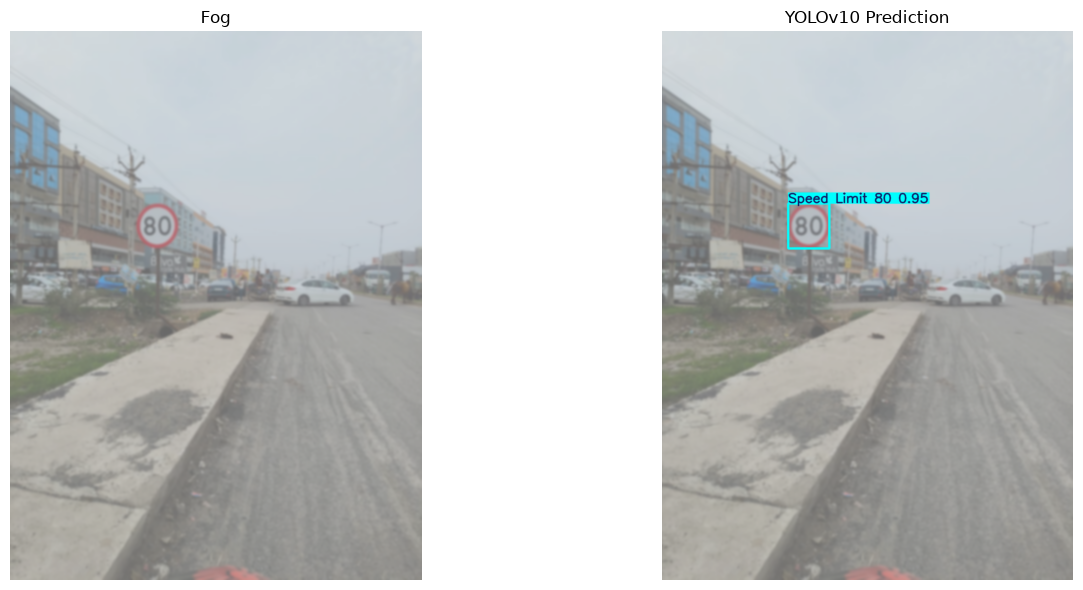

,No.,Traffic Sign,Confidence (%),Width (px),Height (px)
0,1,Speed Limit 80,94.91,96,105


⏱ Total Execution Time : 101.89 ms

RAIN


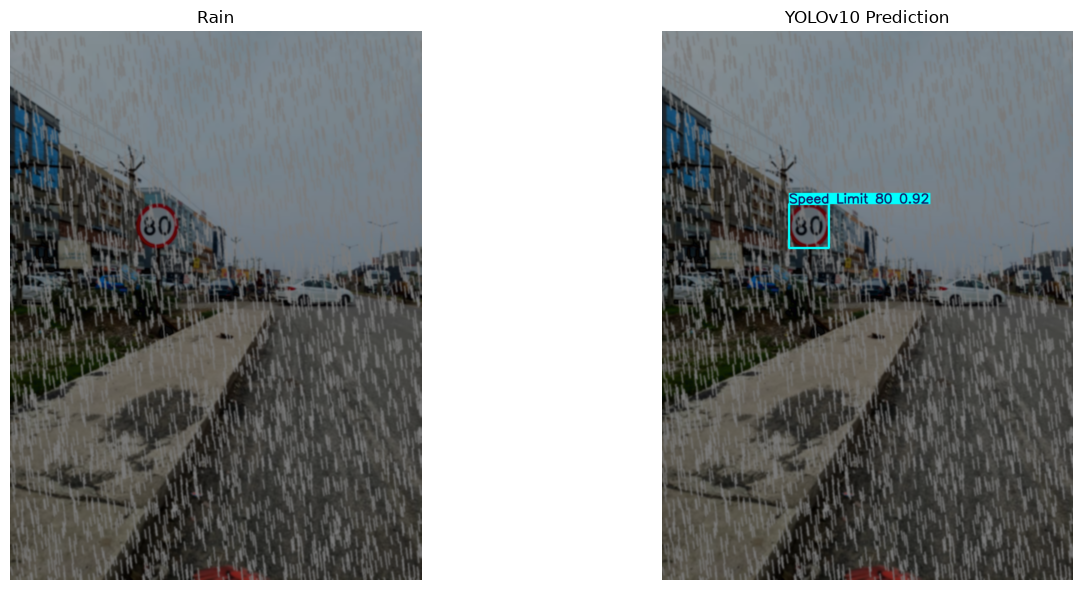

,No.,Traffic Sign,Confidence (%),Width (px),Height (px)
0,1,Speed Limit 80,92.32,93,103


⏱ Total Execution Time : 133.65 ms

GAUSSIAN BLUR


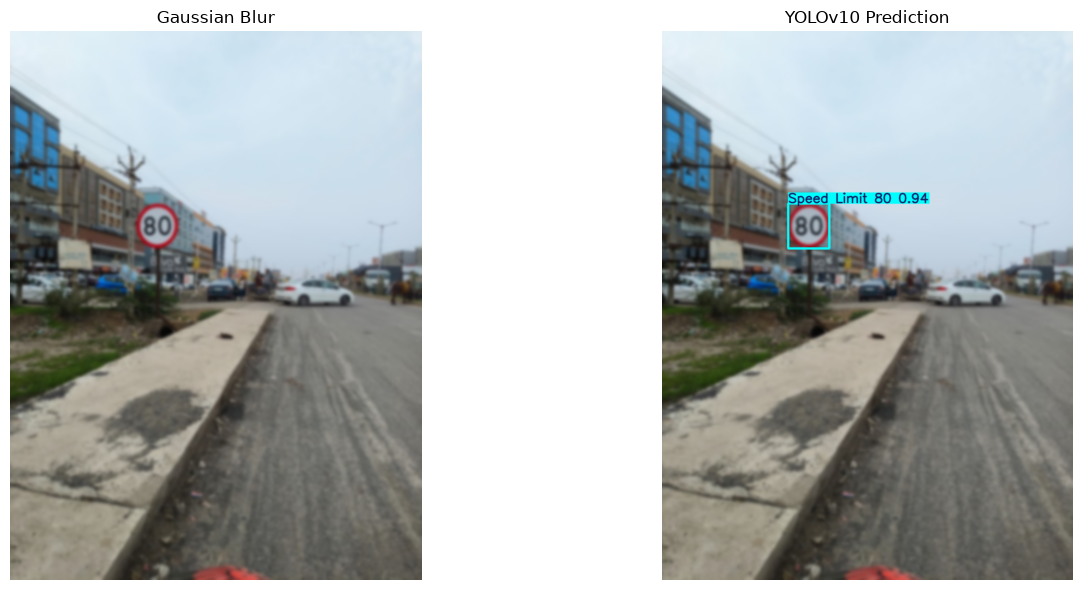

,No.,Traffic Sign,Confidence (%),Width (px),Height (px)
0,1,Speed Limit 80,93.63,96,105


⏱ Total Execution Time : 119.79 ms


In [9]:
# ==========================================================
# Test Original + Filtered Images (YOLOv11n)
# ==========================================================
import time

def night_vision(img):
    img = img.copy()

    # Convert BGR → HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)

    # Darken image
    hsv[:, :, 2] *= 0.45

    # Reduce saturation
    hsv[:, :, 1] *= 0.70

    hsv[:, :, 2] = np.clip(hsv[:, :, 2], 0, 255)
    hsv[:, :, 1] = np.clip(hsv[:, :, 1], 0, 255)

    # Convert HSV → BGR
    night = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    # Slight green tint
    night[:, :, 1] = cv2.add(night[:, :, 1], 20)

    return night

def fog_filter(img):

    img = img.copy()

    h, w = img.shape[:2]

    # White fog layer
    fog = np.full((h, w, 3), 255, dtype=np.uint8)

    # Dense fog
    foggy = cv2.addWeighted(img, 0.60, fog, 0.40, 0)

    # Strong blur
    foggy = cv2.GaussianBlur(foggy, (15, 15), 0)

    # Lower contrast
    foggy = cv2.convertScaleAbs(
        foggy,
        alpha=0.80,
        beta=20
    )

    return foggy


def rain_filter(img):

    rain = img.copy()

    h, w = rain.shape[:2]

    # Dense rain
    for _ in range(3500):

        x = np.random.randint(0, w)
        y = np.random.randint(0, h)

        length = np.random.randint(18, 35)

        cv2.line(
            rain,
            (x, y),
            (x + 3, y + length),
            (210, 210, 210),
            2
        )

    # Heavy blur
    rain = cv2.GaussianBlur(rain, (9, 9), 1.8)

    # Darker rainy weather
    rain = cv2.convertScaleAbs(
        rain,
        alpha=0.65,
        beta=-15
    )

    return rain

def gaussian_filter(img):

    img = img.copy()

    return cv2.GaussianBlur(img, (21, 21), 0)
# ---------------- Select Image ----------------

root = Tk()
root.withdraw()
root.attributes("-topmost", True)

image_path = filedialog.askopenfilename(
    title="Select Traffic Sign Image",
    filetypes=[("Image Files", "*.jpg *.jpeg *.png *.bmp *.webp")]
)

root.destroy()

if image_path == "":
    print("No image selected.")
    raise SystemExit

print("Selected Image:", image_path)

# Read image
original = cv2.imread(image_path)

images = {
    "Original": original.copy(),
    "Night Vision": night_vision(original.copy()),
    "Fog": fog_filter(original.copy()),
    "Rain": rain_filter(original.copy()),
    "Gaussian Blur": gaussian_filter(original.copy())
}

for title, img in images.items():

    print("\n" + "=" * 70)
    print(title.upper())
    print("=" * 70)

    start = time.time()

    results = best_model.predict(
        source=img,
        conf=0.25,
        imgsz=640,
        save=False,
        verbose=False
    )

    end = time.time()

    result = results[0]

    annotated = result.plot()

    original_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    predicted_display = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15,6))

    plt.subplot(1,2,1)
    plt.imshow(original_display)
    plt.title(title)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(predicted_display)
    plt.title("YOLOv10 Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    detections = []

    for i, box in enumerate(result.boxes):

        cls = int(box.cls[0])
        conf = float(box.conf[0]) * 100

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        detections.append({
            "No.": i + 1,
            "Traffic Sign": result.names[cls],
            "Confidence (%)": round(conf, 2),
            "Width (px)": x2 - x1,
            "Height (px)": y2 - y1
        })

    if detections:
        display(pd.DataFrame(detections))
    else:
        print("❌ No Traffic Sign Detected.")

    print(f"⏱ Total Execution Time : {(end-start)*1000:.2f} ms")